In [1]:
!pip install -q transformers torch torchvision pillow

In [2]:
from transformers import pipeline

print("⏳ Cargando CLIP...")

modelo_clip = pipeline(
    "zero-shot-image-classification",
    model="openai/clip-vit-base-patch32"
)

print("✅ CLIP está listo")

⏳ Cargando CLIP...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

✅ CLIP está listo


Saving BA8E2398-BFCD-449E-976C-CFF39706EFB5.JPG to BA8E2398-BFCD-449E-976C-CFF39706EFB5 (2).JPG


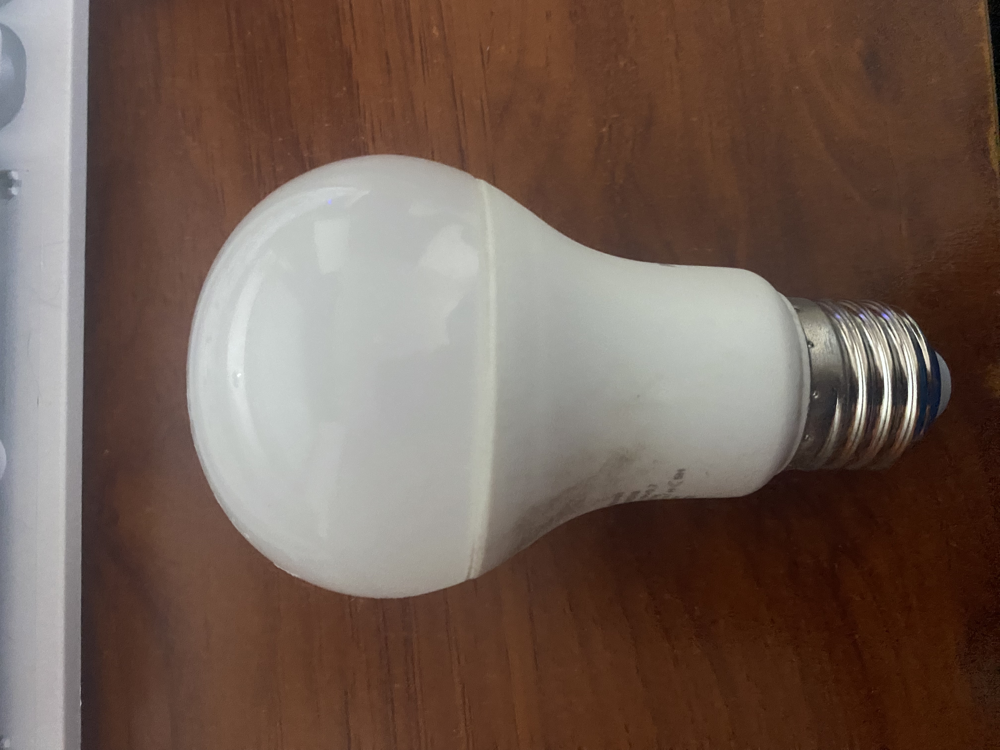

✅ Imagen cargada: BA8E2398-BFCD-449E-976C-CFF39706EFB5 (2).JPG


In [3]:
£from PIL import Image
from google.colab import files

subido = files.upload()

nombre_archivo = list(subido.keys())[0]

imagen = Image.open(nombre_archivo).convert("RGB")

display(imagen)

print("✅ Imagen cargada:", nombre_archivo)

In [4]:
!pip install -q diffusers accelerate safetensors

In [5]:
import torch
import diffusers

print("PyTorch:", torch.__version__)
print("Diffusers:", diffusers.__version__)
print("GPU disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu130
Diffusers: 0.40.0
GPU disponible: True
GPU: Tesla T4


In [6]:
import torch
from diffusers import StableDiffusionXLPipeline

print("⏳ Cargando SDXL...")

pipe = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
    use_safetensors=True,
    low_cpu_mem_usage=True
)

pipe.enable_model_cpu_offload()
pipe.enable_attention_slicing()

print("✅ SDXL está listo")

⏳ Cargando SDXL...


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

✅ SDXL está listo


In [7]:
def analizar_categoria(imagen, candidatos, cantidad=3):
    resultados = modelo_clip(
        imagen,
        candidate_labels=candidatos
    )

    return resultados[:cantidad]


def analizar_objeto(imagen):

    # Objeto
    candidatos_objetos = [
        "a light bulb",
        "a bottle",
        "a cup",
        "a mug",
        "a book",
        "a pen",
        "a pencil",
        "a phone",
        "a lamp",
        "a plant",
        "a flower",
        "a vase",
        "a spoon",
        "a fork",
        "a plate",
        "a bowl",
        "a toy",
        "a clock",
        "a watch",
        "a pair of glasses",
        "a remote control",
        "a shoe",
        "a key",
        "a box",
        "a household object"
    ]

    objeto = analizar_categoria(
        imagen,
        candidatos_objetos,
        cantidad=1
    )

    # Forma
    formas = [
        "a round object",
        "a spherical object",
        "an oval object",
        "a rectangular object",
        "an elongated object",
        "a cylindrical object",
        "an irregular object"
    ]

    forma = analizar_categoria(imagen, formas)

    # Color
    colores = [
        "a white object",
        "a black object",
        "a gray object",
        "a red object",
        "a blue object",
        "a green object",
        "a yellow object",
        "a brown object",
        "a transparent object",
        "a multicolored object"
    ]

    color = analizar_categoria(imagen, colores)

    # Material
    materiales = [
        "a plastic object",
        "a glass object",
        "a metal object",
        "a ceramic object",
        "a wooden object",
        "a paper object",
        "a fabric object",
        "a stone object",
        "a shiny object",
        "a matte object"
    ]

    material = analizar_categoria(imagen, materiales)

    # Textura
    texturas = [
        "a smooth surface",
        "a rough surface",
        "a textured surface",
        "a glossy surface",
        "a translucent surface",
        "a soft surface",
        "a hard surface"
    ]

    textura = analizar_categoria(imagen, texturas)

    return {
        "objeto": objeto,
        "forma": forma,
        "color": color,
        "material": material,
        "textura": textura
    }

In [8]:
perfil = analizar_objeto(imagen)

print("🔎 PERFIL VISUAL")
print("=" * 40)

for categoria, resultados in perfil.items():
    print(f"\n{categoria.upper()}")

    for resultado in resultados:
        print(
            f"  • {resultado['label']} "
            f"→ {resultado['score']:.2%}"
        )

🔎 PERFIL VISUAL

OBJETO
  • a light bulb → 91.79%

FORMA
  • a cylindrical object → 36.38%
  • an irregular object → 28.90%
  • a round object → 13.84%

COLOR
  • a white object → 89.21%
  • a transparent object → 3.75%
  • a gray object → 2.16%

MATERIAL
  • a plastic object → 77.73%
  • a shiny object → 7.26%
  • a matte object → 5.73%

TEXTURA
  • a hard surface → 30.79%
  • a translucent surface → 30.03%
  • a soft surface → 16.91%


In [9]:
opciones = [
    "Forma",
    "Color",
    "Textura",
    "Sorpréndeme"
]

print("✨ ¿Qué quieres conservar?")

for i, opcion in enumerate(opciones, 1):
    print(f"{i}. {opcion}")

✨ ¿Qué quieres conservar?
1. Forma
2. Color
3. Textura
4. Sorpréndeme


In [10]:
eleccion = int(input("Escribe el número de tu elección: "))

opcion_elegida = opciones[eleccion - 1]

print(f"\n✨ Has elegido conservar: {opcion_elegida}")

Escribe el número de tu elección: 1

✨ Has elegido conservar: Forma


In [11]:
caracteristica_elegida = perfil[opcion_elegida.lower()]

print(f"✨ Característica seleccionada: {opcion_elegida}")
print()

for resultado in caracteristica_elegida:
    print(
        f"• {resultado['label']} "
        f"→ {resultado['score']:.2%}"
    )

✨ Característica seleccionada: Forma

• a cylindrical object → 36.38%
• an irregular object → 28.90%
• a round object → 13.84%


In [12]:
prompt = """
Create a single surrealist metamorphosis emerging from the visual memory
of an ordinary everyday object.

The participant chose to preserve FORM.

Use the object's geometry as a subtle visual seed:
curves, volume, proportions, elongated structures,
rounded contours and irregular shapes.

Do not reproduce the original object.
Do not create bottles, containers, lamps, light bulbs,
products, shelves or collections of objects.

Do not create a repeated pattern.
Do not create multiple versions of the same thing.

Instead, allow the original geometry to evolve into ONE unexpected
surreal entity or environment.

It could become an impossible organism, strange architecture,
a celestial body, a landscape, a portal, a living structure,
or something that has no recognizable real-world category.

The transformation should feel like discovering something
that was hidden inside the object's form.

The result should be mysterious, poetic and visually surprising.

Single central composition.
Surrealist fine-art painting.
Dreamlike atmosphere.
Organic impossible forms.
Visible expressive brushstrokes.
Painted canvas texture.
Atmospheric depth.
Cohesive artistic composition.
Museum-quality surrealist artwork.
"""

print(prompt)


Create a single surrealist metamorphosis emerging from the visual memory
of an ordinary everyday object.

The participant chose to preserve FORM.

Use the object's geometry as a subtle visual seed:
curves, volume, proportions, elongated structures,
rounded contours and irregular shapes.

Do not reproduce the original object.
Do not create bottles, containers, lamps, light bulbs,
products, shelves or collections of objects.

Do not create a repeated pattern.
Do not create multiple versions of the same thing.

Instead, allow the original geometry to evolve into ONE unexpected
surreal entity or environment.

It could become an impossible organism, strange architecture,
a celestial body, a landscape, a portal, a living structure,
or something that has no recognizable real-world category.

The transformation should feel like discovering something
that was hidden inside the object's form.

The result should be mysterious, poetic and visually surprising.

Single central composition.
Surreali

In [13]:
negative_prompt = """
photograph, product photography, catalog, still life,
bottle, bottles, container, containers, light bulb,
lamp, shelf, shelves, repeated objects, multiple objects,
pattern, grid, collage, symmetrical repetition,
duplicate objects, identical objects, text, letters, logo
"""

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (220 > 77). Running this sequence through the model will result in indexing errors
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer CLIPTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ["shelves or collections of objects . do not create a repeated pattern . do not create multiple versions of the same thing . instead , allow the original geometry to evolve into one unexpected surreal entity or environment . it could become an impossible organism , strange architecture

🎨 Generando una segunda interpretación...


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (220 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ["shelves or collections of objects . do not create a repeated pattern . do not create multiple versions of the same thing . instead , allow the original geometry to evolve into one unexpected surreal entity or environment . it could become an impossible organism , strange architecture , a celestial body , a landscape , a portal , a living structure , or something that has no recognizable real - world category . the transformation should feel like discovering something that was hidden inside the object 's form . the result should be mysterious , poetic and visually surprising . single central composition . surrealist fine - art painting . dreamlike atmosphere . organic impossible forms . visi

  0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


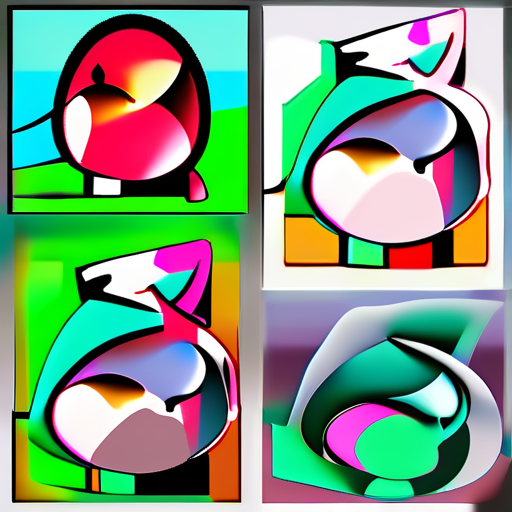

In [14]:
print("🎨 Generando una segunda interpretación...")

imagen_generada = pipe(
    prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=20,
    guidance_scale=6.5,
    height=512,
    width=512
).images[0]

display(imagen_generada)